# Kaggle – DataTops®
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn 
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

## 2. Datos

In [39]:
df = pd.read_csv('./data/train.csv', encoding='latin-1')
# train es lo que se divide en train y test 80 20, no usamos train y test como parte del mismo dataset de train

### 2.1 Exploración de los datos

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    object 
 2   Product           912 non-null    object 
 3   TypeName          912 non-null    object 
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    object 
 6   Cpu               912 non-null    object 
 7   Ram               912 non-null    object 
 8   Memory            912 non-null    object 
 9   Gpu               912 non-null    object 
 10  OpSys             912 non-null    object 
 11  Weight            912 non-null    object 
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), object(10)
memory usage: 92.8+ KB


In [41]:
# Tu código aquí
df.describe(include='all')


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
count,912.000000,912,912,912,912.000000,912,912,912,912,912,912,912,912.000000
unique,NaN,19,480,6,NaN,36,107,9,37,93,9,165,NaN
top,NaN,Lenovo,XPS 13,Notebook,NaN,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg,NaN
freq,NaN,202,23,509,NaN,349,124,434,282,185,741,91,NaN
mean,650.312500,NaN,NaN,NaN,14.981579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1111.724090
std,382.727748,NaN,NaN,NaN,1.436719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,687.959172
min,2.000000,NaN,NaN,NaN,10.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,174.000000
25%,324.750000,NaN,NaN,NaN,14.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,589.000000
50%,636.500000,NaN,NaN,NaN,15.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,978.000000
75%,982.250000,NaN,NaN,NaN,15.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1483.942500


In [42]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [43]:
#ver valores faltantes
df.isna().sum().sort_values(ascending=False)

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_in_euros      0
dtype: int64

### 2.2 Definir X e y


In [44]:
# Tu código aquí y sería el precio
X = df.drop(columns="Price_in_euros")
y = df["Price_in_euros"]


### 2.3 Dividir en train y test

In [45]:
# Tu código aquí
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
train = X_train.copy()
test = X_test.copy()
train["Price_in_euros"] = y_train

In [47]:
train.shape

(729, 13)

### 3.0 MiniEDA sólo sobre TRAIN

In [48]:
# --- 1. Dimensiones y estructura ---
print("Dimensiones del train:", train.shape)
print("\nInformación del dataset:")
train.info()

Dimensiones del train: (729, 13)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 25 to 102
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         729 non-null    int64  
 1   Company           729 non-null    object 
 2   Product           729 non-null    object 
 3   TypeName          729 non-null    object 
 4   Inches            729 non-null    float64
 5   ScreenResolution  729 non-null    object 
 6   Cpu               729 non-null    object 
 7   Ram               729 non-null    object 
 8   Memory            729 non-null    object 
 9   Gpu               729 non-null    object 
 10  OpSys             729 non-null    object 
 11  Weight            729 non-null    object 
 12  Price_in_euros    729 non-null    float64
dtypes: float64(2), int64(1), object(10)
memory usage: 79.7+ KB


In [49]:
# --- 2. Duplicados ---
print("\nDuplicados:", train.duplicated().sum())


Duplicados: 0


In [50]:
# --- 3. Valores únicos por columna ---
print("\nValores únicos por columna:")
print(train.nunique().sort_values())


Valores únicos por columna:
TypeName              6
Ram                   8
OpSys                 9
Inches               15
Company              17
ScreenResolution     33
Memory               33
Gpu                  84
Cpu                  93
Weight              148
Product             408
Price_in_euros      504
laptop_ID           729
dtype: int64


Distribución del target Price_in_euros

Distribución del target muy sesgado a la derecha que afectará a modelos lineales


Descripción del target (Price):
count     729.000000
mean     1103.789314
std       672.778174
min       191.900000
25%       598.000000
50%       985.000000
75%      1460.000000
max      6099.000000
Name: Price_in_euros, dtype: float64


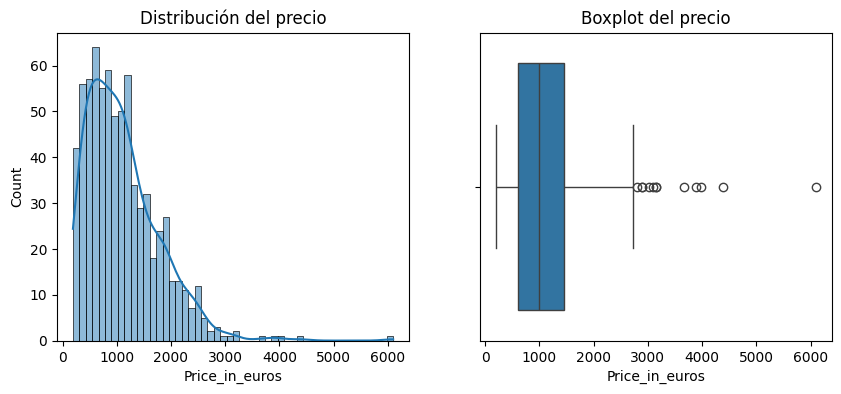

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
# --- 4. Distribución del target ---
print("\nDescripción del target (Price):")
print(train["Price_in_euros"].describe())

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(train["Price_in_euros"], bins=50, kde=True)
plt.title("Distribución del precio")

plt.subplot(1,2,2)
sns.boxplot(x=train["Price_in_euros"])
plt.title("Boxplot del precio")
plt.show()

In [52]:
# --- 5. Distribución de variables numéricas ---
print("\nDescripción de variables numéricas:")
print(train.describe())


Descripción de variables numéricas:
         laptop_ID      Inches  Price_in_euros
count   729.000000  729.000000      729.000000
mean    656.503429   15.002881     1103.789314
std     384.781046    1.428711      672.778174
min       2.000000   10.100000      191.900000
25%     326.000000   14.000000      598.000000
50%     651.000000   15.600000      985.000000
75%     990.000000   15.600000     1460.000000
max    1320.000000   17.300000     6099.000000


In [53]:
# --- 6. Distribución de variables categóricas ---
print("\nCardinalidad de variables categóricas:")
cat_cols = train.select_dtypes("object").columns
for col in cat_cols:
    print(f"{col}: {train[col].nunique()} valores")


Cardinalidad de variables categóricas:
Company: 17 valores
Product: 408 valores
TypeName: 6 valores
ScreenResolution: 33 valores
Cpu: 93 valores
Ram: 8 valores
Memory: 33 valores
Gpu: 84 valores
OpSys: 9 valores
Weight: 148 valores



Correlación con el precio:
Price_in_euros    1.000000
Inches            0.051334
laptop_ID         0.028475
Name: Price_in_euros, dtype: float64


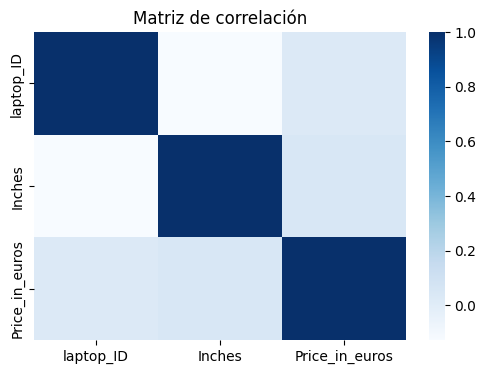

In [54]:
# --- 7. Correlación numérica ---
print("\nCorrelación con el precio:")
corr = train.corr(numeric_only=True)["Price_in_euros"].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(6,4))
sns.heatmap(train.corr(numeric_only=True), annot=False, cmap="Blues")
plt.title("Matriz de correlación")
plt.show()

In [55]:
# --- 8. Identificación de columnas que requieren ingeniería ---
print("\nColumnas que requieren ingeniería de variables:")
cols_engineering = ["ScreenResolution", "Cpu", "Gpu", "Memory", "Ram", "Weight"]
print(cols_engineering)


Columnas que requieren ingeniería de variables:
['ScreenResolution', 'Cpu', 'Gpu', 'Memory', 'Ram', 'Weight']


In [56]:
# --- 9. Comprobación de nulos ---
print("\nNulos por columna:")
print(train.isna().sum())


Nulos por columna:
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_in_euros      0
dtype: int64


In [57]:
# --- 10. Comprobación de leakage ---
print("\nComprobación rápida de leakage:")
print("Columnas duplicadas:", train.T.duplicated().sum())


Comprobación rápida de leakage:
Columnas duplicadas: 0


In [58]:
df.describe(include='all')

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
count,912.000000,912,912,912,912.000000,912,912,912,912,912,912,912,912.000000
unique,NaN,19,480,6,NaN,36,107,9,37,93,9,165,NaN
top,NaN,Lenovo,XPS 13,Notebook,NaN,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg,NaN
freq,NaN,202,23,509,NaN,349,124,434,282,185,741,91,NaN
mean,650.312500,NaN,NaN,NaN,14.981579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1111.724090
std,382.727748,NaN,NaN,NaN,1.436719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,687.959172
min,2.000000,NaN,NaN,NaN,10.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,174.000000
25%,324.750000,NaN,NaN,NaN,14.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,589.000000
50%,636.500000,NaN,NaN,NaN,15.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,978.000000
75%,982.250000,NaN,NaN,NaN,15.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1483.942500


- No hay nulos  
- Price_in_euros está sesgado a la derecha
- Memory, Cpu, Gpu, ScreenResolution necesitan modificación
- Ram y Weight vienen con unidades, hay que limpiarlas y pasarlas a int
- Cardinalidades normales


## 3. Procesado de datos

> 🚨 **Data leakage:** si usas un scaler, haz **`.fit()` SOLO sobre `X_train`** y luego aplica `.transform()` sobre `X_train` y `X_test` por separado.
>
> Recuerda también que **todo lo que hagas aquí deberás replicarlo después en `test.csv`** (sección 6).

In [59]:
from clean_dataset import clean_dataset

### 3.1 Limpieza de features

In [60]:
train_clean = clean_dataset(train)
test_clean = clean_dataset(test)

X_train = train_clean.drop(columns="Price_in_euros")
y_train = train_clean["Price_in_euros"]
X_test = test_clean.copy()

In [61]:
# detectar categóricas
categorical_cols = [col for col in X_train.columns if X_train[col].dtype == "object"]

In [62]:
#CREAR VERSION NATIVA (CATEGORY) PARA XGBOOST / CATBOOST
X_train_native = X_train.copy()
X_test_native = X_test.copy()

for col in categorical_cols:
    X_train_native[col] = X_train_native[col].astype("category")
    X_test_native[col] = X_test_native[col].astype("category")

# Índices de columnas categóricas
cat_features_idx = [
    X_train_native.columns.get_loc(col)
    for col in categorical_cols
]
# COMPROBAR
print("Dtypes native:")
print(X_train_native.dtypes)

Dtypes native:
Ram                int64
Weight           float64
SSD                int64
HDD                int64
Flash              int64
Hybrid             int64
Resolution_X       int64
Resolution_Y       int64
Touchscreen        int64
Cpu_brand       category
Cpu_model       category
Gpu_brand       category
dtype: object


### 3.2 Escalado y Baseline

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [64]:
# seleccionar columnas numéricas
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_cols])
X_test_scaled = scaler.transform(X_test[num_cols])


## 4. Modelado

modelos basados en árboles son adecuados porque caputran relaciones no lineales , las relaciones entre ram, cpu o gpu no es lineal. y funcionana bien condatasets medianos
Por lo que modelaremos con XGBoostRegressor, GradientBoostingRegressor y RandomForestRegressor

Como base line usaremos LinearRegression y Ridge

In [65]:
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [66]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)


X_train_ohe = preprocessor.fit_transform(X_train)
X_test_ohe = preprocessor.transform(X_test)


In [67]:
models = {
    # Baseline (usa escalado si lo tienes)
    "LinearRegression": {
        "model": LinearRegression(),
        "X": X_train_scaled,   # o X_train_scaled si lo tienes
        "X_test": X_train_scaled
    },

    # Modelos con OHE
    "RandomForest": {
        "model": RandomForestRegressor(
            n_estimators=300, random_state=42, n_jobs=-1
        ),
        "X": X_train_ohe,
        "X_test": X_test_ohe
    },

    "GradientBoosting": {
        "model": GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),
        "X": X_train_ohe,
        "X_test": X_test_ohe
    },

    # Modelos nativos (sin OHE)
    "XGBoost": {
        "model": XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            tree_method="hist",
            enable_categorical=True
        ),
        "X": X_train_native,
        "X_test": X_test_native
    },

    "CatBoost": {
        "model": CatBoostRegressor(
            depth=8,
            learning_rate=0.05,
            iterations=500,
            random_state=42,
            verbose=0,
            cat_features=cat_features_idx
        ),
        "X": X_train_native,
        "X_test": X_test_native
    }
}




### 4.1 Entrenamiento

In [68]:
print(X_train_native.dtypes)


Ram                int64
Weight           float64
SSD                int64
HDD                int64
Flash              int64
Hybrid             int64
Resolution_X       int64
Resolution_Y       int64
Touchscreen        int64
Cpu_brand       category
Cpu_model       category
Gpu_brand       category
dtype: object


In [69]:
# Tu código aquí


results = {}

for name, cfg in models.items():
    print(f"\n=== Entrenando {name} ===")
    model = cfg["model"]
    Xtr = cfg["X"]

    model.fit(Xtr, y_train)
    pred_train = model.predict(Xtr)

    rmse = np.sqrt(mean_squared_error(y_train, pred_train))
    results[name] = rmse

    print(f"{name} — RMSE Train: {rmse:.4f}")


=== Entrenando LinearRegression ===
LinearRegression — RMSE Train: 394.0386

=== Entrenando RandomForest ===
RandomForest — RMSE Train: 145.2831

=== Entrenando GradientBoosting ===
GradientBoosting — RMSE Train: 216.0137

=== Entrenando XGBoost ===
XGBoost — RMSE Train: 111.1360

=== Entrenando CatBoost ===
CatBoost — RMSE Train: 201.0832


### 4.2 Métricas

Recuerda que en la competición se evalúa con **RMSE**.

In [70]:
# Tu código aquí
print("\n=== RESUMEN FINAL DE RMSE ===")
for name, rmse in results.items():
    print(f"{name}: {rmse:.4f}")


=== RESUMEN FINAL DE RMSE ===
LinearRegression: 394.0386
RandomForest: 145.2831
GradientBoosting: 216.0137
XGBoost: 111.1360
CatBoost: 201.0832


### 4.3 Optimización (up to you 🫰🏻)

In [71]:
# Tu código aquí


## 5. Reentrenamiento sobre todos los datos de `train.csv`

Una vez afinado el modelo, reentrenamos con **todos** los datos disponibles antes de predecir sobre `test.csv`.

> ¿Por qué? El split anterior era solo para validar localmente. Para la submission final queremos aprovechar el 100% de los datos de entrenamiento.

In [72]:
# Tu código aquí

#  se elegiría el mejor modelo con validación cruzada se vería contra test (el 20% de train) usamos el resto del test 
# una vez optimizado el modelo se reentrena con el 100 de train, y al hacer la predicción de test porque lo que nos van a evaluar es el test
# MEJOR MODELO XGBOOST
train_clean = clean_dataset(df)

X_full = train_clean.drop(columns="Price_in_euros")
y_full = train_clean["Price_in_euros"]


In [73]:
# ============================================================
# 2. DETECTAR CATEGÓRICAS
# ============================================================

categorical_cols = [col for col in X_full.columns if X_full[col].dtype == "object"]

In [ ]:
# ============================================================
# 3. OHE PARA XGBOOST (fit SOLO en train)
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

# Fit-transform SOLO en train
# X_full_ohe = preprocessor.fit_transform(X_full)
X_full_ohe = preprocessor.fit_transform(X_full)

# Transform SOLO en test


NotFittedError: This ColumnTransformer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
# ============================================================
# 4. REENTRENAR EL MEJOR MODELO (XGBOOST)
# ============================================================

best_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    enable_categorical=True
)
best_model.fit(X_full_ohe, y_full)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

---
# PARTE 2: Predicción y submission

Una vez tengas el modelo listo, toca predecir sobre `test.csv` y generar el archivo de submission.

## 6. Carga los datos de `test.csv`

In [ ]:
X_pred = pd.read_csv('./data/test.csv', encoding='latin-1')
X_pred.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


## 7. Replica el procesado en `test.csv`

> ⚠️ Usa `.transform()`, **nunca `.fit_transform()`** sobre los datos de test.
>
> Lo único que **no puedes hacer** es eliminar filas.

In [ ]:
# Tu código aquí
# 0. Guardar los IDs ANTES de limpiar
test_ids = X_pred["laptop_ID"].copy()
# 1. Limpieza igual que en train
test_clean = clean_dataset(X_pred)
X_test_ohe = preprocessor.transform(test_clean)
# 2. Convertir categóricas a category igual que en train
for col in categorical_cols:
    test_clean[col] = test_clean[col].astype("category")
    
pred_test = best_model.predict(X_test_ohe)

ValueError: Feature shape mismatch, expected: 20, got 19

## 8. Genera la submission

### 8.1 ¿Qué formato espera Kaggle?

In [ ]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


### 8.2 Crea tu submission

In [ ]:
# Tu código aquí
submission = pd.DataFrame({
    "laptop_ID": test_ids,
    "Price_in_euros": pred_test
})

ValueError: array length 183 does not match index length 391

### 8.3 Chequeador

Pásale el chequeador antes de subir a Kaggle. Si todo está bien, guardará el CSV automáticamente con un nombre único.

In [ ]:
def checker(df_to_submit, sample, filename=None):
    """
    Valida que tu submission tenga la forma requerida por Kaggle.
    Si es correcta, guarda el CSV listo para subir.
    Si no, lee el mensaje de error y corrígelo.
    """
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        print('   Revisa que no hayas borrado filas del test ni añadido/quitado columnas.')
        return

    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        print(f'   Tus columnas:       {list(df_to_submit.columns)}')
        print(f'   Columnas esperadas: {list(sample.columns)}')
        return

    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission. Revisa que no hayas reordenado el test.csv.')
        return

    if filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'submission_{timestamp}.csv'

    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [ ]:
checker(submission, sample)